##### <h1 style="text-align:center"> Drexel University </h1>
<h2 style = "text-align:center"> College of Computing and Informatics</h2>
<h2 style = "text-align:center">DSCI 631: Applied Machine Learning</h2>
<h3 style = "text-align:center">Assignment 3</h3>
<h4> </h4>


<h3 style="color:red; font-weight:bold; text-decoration: underline">DON'T FORGET TO PUT YOUR TEAM MEMBERS' NAMES BELOW</h3>
### TEAM MEMBERS: <h3>Sudhaman Chandrasekaran</h3>

### A. Assignment Overview
This assignment provides the opportunity for you to practice with various skills in unsupervised learning, and convolution neural network

### B. What to Hand In

Sumbit a completed this Jupyter notebook.

### C. How to Hand In

Submit your Jupyter notebook file through the course website in the Blackboard Learn system.

### D. When to Hand In

1. Submit your assignment no later than 11:59 pm in the due date.
2. There will be a 10% (absolute value) deduction for each day of lateness, to a maximum of 3 days; assignments will not be accepted beyond that point. Missing work will earn a zero grade.

### E. Written Presentation Requirements (if applicable)
Images must be clear and legible. Assignments will be judged on the basis of visual appearance, grammatical correctness, and quality of writing, as well as their contents. Please make sure that the text of your assignments is well-structured, using paragraphs, full sentences, and other features of well-written presentation.

### F. Academic Honesty

Each student is required to submit the Academic Honesty Form at the beginning of the term to cover all the deliverables (for example: assignments, projects, quizzes). Each piece of work must be original. That means, individual quizzes must be done individually without discussing and collaborating with anybody else. Team assignments must be written and programmed by your own team members. No team should copy any piece of work from other teams. The Drexel University Academic Honesty Rules and Procedures (as stated in the student handbook) will be adhered to strictly.  

### G. Marking Schemes:

Marking assignments will be based on several aspects: presentation, correctness and coding styles.

For programming questions, 10% of the mark will be judged on the coding style.

The following is a set of guidelines for the coding style in this course:
1. Write a good comment.
2. Use appropriate indentations to indicate control flows and blocks of code.
3. When breaking up a long line, break it before an operator, not after.

### H. Answer the following questions:
**Your answer should be combined with code and brief text answer.** Please ensure that your Jupyter notebook does not have too much spurious output. If you like, you can share your notebook in progress with me on Kaggle: leiwangv (lw474@drexel.edu)

### Data for part 1 in this assignment:
* URL: https://www.kaggle.com/datasets/abdelazizsami/cdc-diabetes-health-indicators?select=diabetes_binary_health_indicators_BRFSS2015.csv [only dataset to look into: diabetes_binary_health_indicators_BRFSS2015.csv]

* In this assignment, you should work without the ground truth labels as much as possible. Often inspecting and visualizing the data is the only way to understand the result of clustering and outlier detection.
* For Questions 1-2 visualization, you should look at the plots before making use of the ground truth labels first, then use the ground truth labels (`Diabetes_binary`) to color the points in your plots.

#### Question 1-1:
Create plots to visualize the distribution of all features (both jointly and for each class). Describe your observation.

Then visualize the data using PCA (top two principal components). Make another plot of explained variance (%) in PCA. Discuss what would be a good threshold for the number of principal components if you wanted to reduce the dimensionality of the data?

Dataset shape: (253680, 22)

Class distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Class proportions:
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


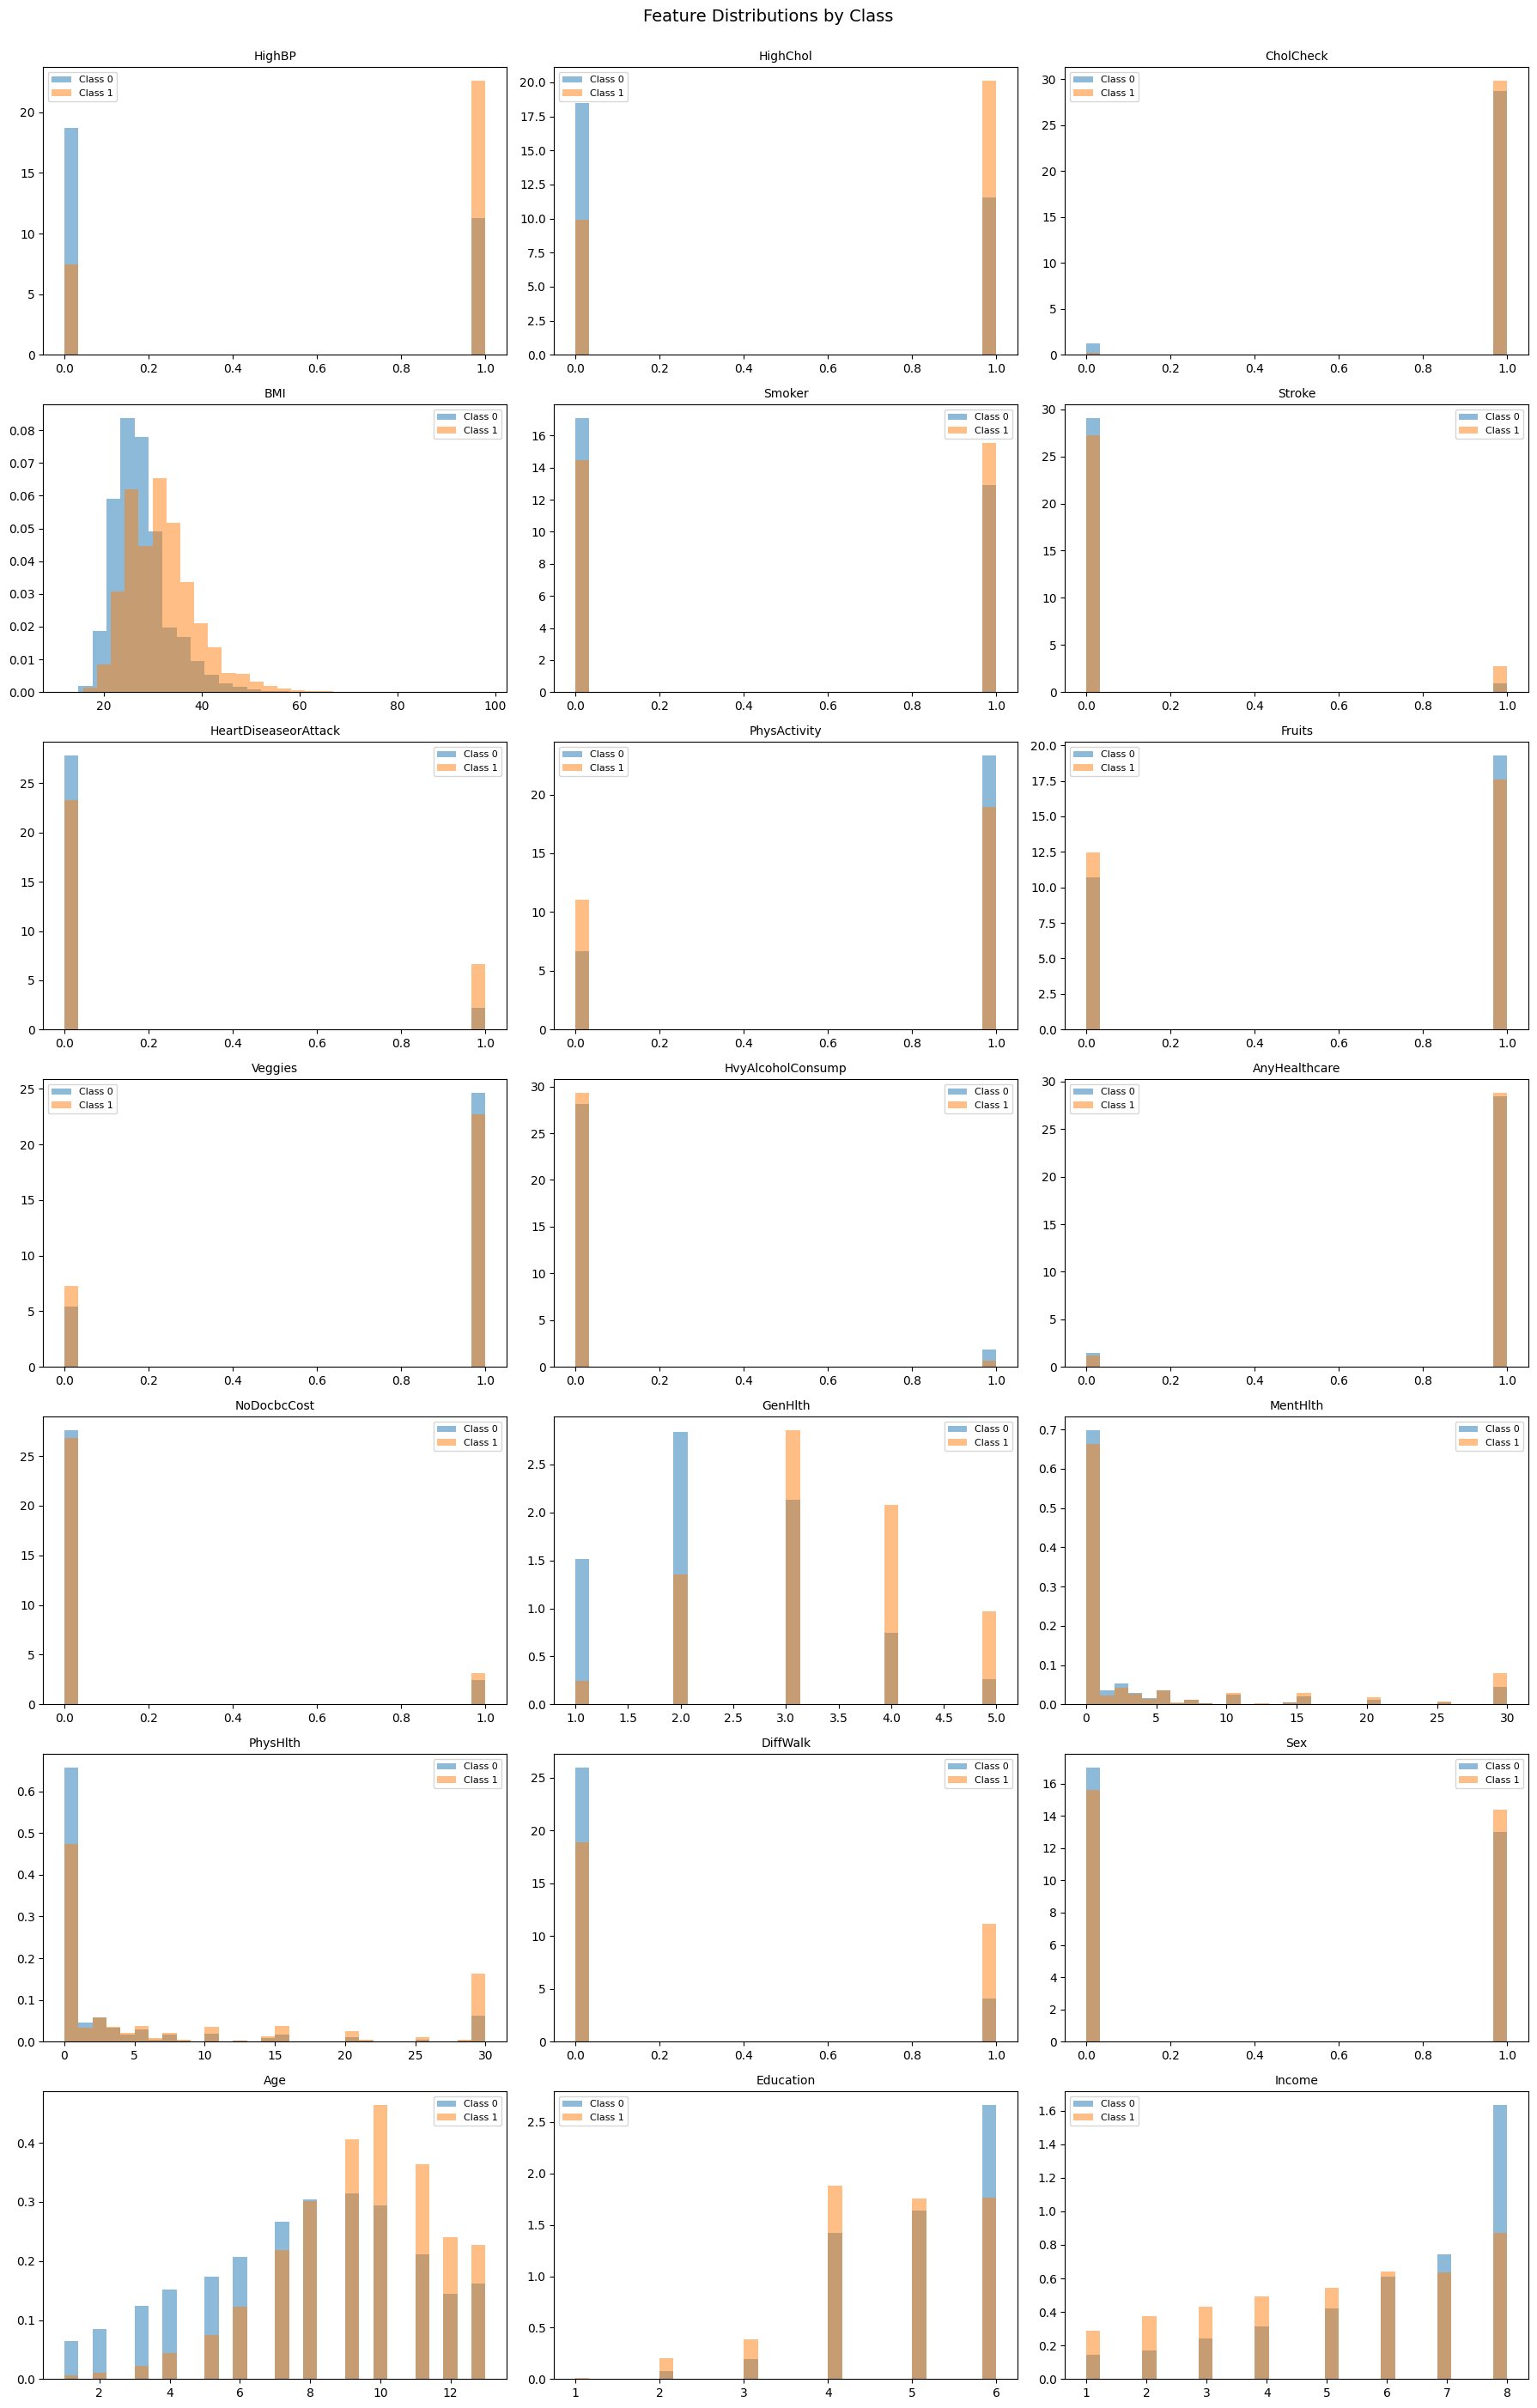

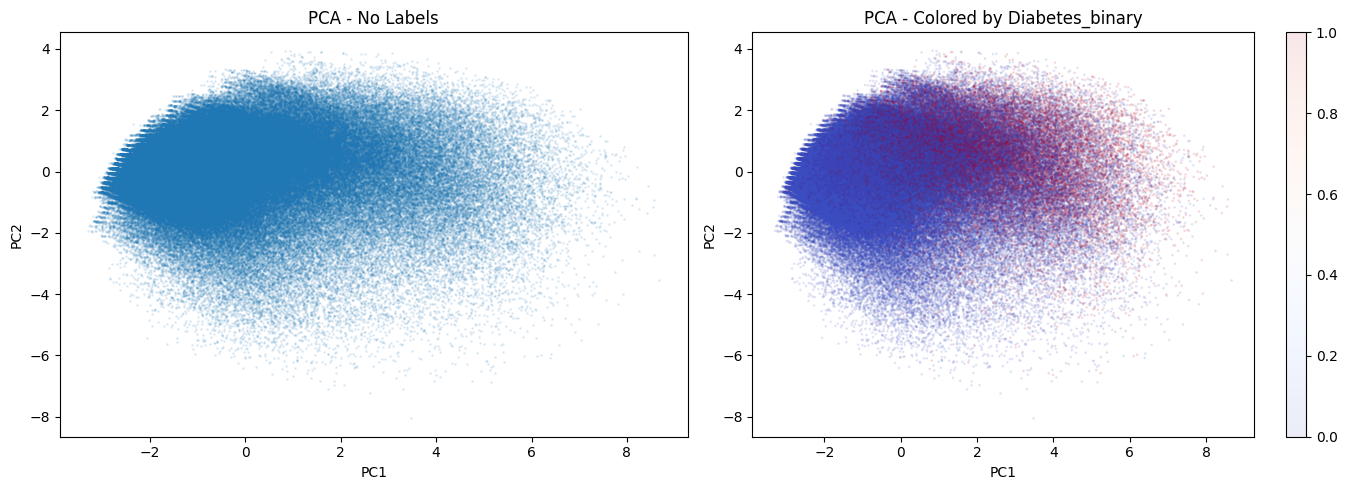

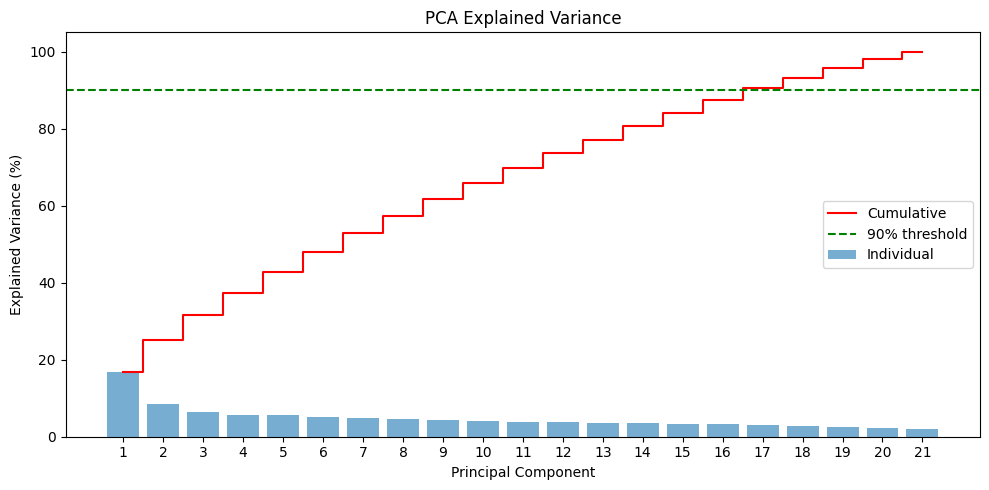


Explained variance per component:
  PC1: 16.71% (cumulative: 16.71%)
  PC2: 8.40% (cumulative: 25.11%)
  PC3: 6.48% (cumulative: 31.59%)
  PC4: 5.67% (cumulative: 37.26%)
  PC5: 5.51% (cumulative: 42.77%)
  PC6: 5.18% (cumulative: 47.95%)
  PC7: 4.92% (cumulative: 52.86%)
  PC8: 4.52% (cumulative: 57.38%)
  PC9: 4.40% (cumulative: 61.78%)
  PC10: 4.19% (cumulative: 65.97%)
  PC11: 3.86% (cumulative: 69.83%)
  PC12: 3.77% (cumulative: 73.61%)
  PC13: 3.56% (cumulative: 77.16%)
  PC14: 3.49% (cumulative: 80.65%)
  PC15: 3.39% (cumulative: 84.04%)
  PC16: 3.35% (cumulative: 87.39%)
  PC17: 3.17% (cumulative: 90.56%)
  PC18: 2.66% (cumulative: 93.21%)
  PC19: 2.43% (cumulative: 95.64%)
  PC20: 2.35% (cumulative: 97.99%)
  PC21: 2.01% (cumulative: 100.00%)

Number of components to reach 90% variance: 17

Observation: The PCA plot shows significant overlap between the two classes,
indicating that the classes are not easily separable in 2D PCA space.
A good threshold for dimensionality reduc

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("data/diabetes_binary_health_indicators_BRFSS2015.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['Diabetes_binary'].value_counts()}")
print(f"\nClass proportions:\n{df['Diabetes_binary'].value_counts(normalize=True)}")

# Separate features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# --- Distribution of all features (jointly and for each class) ---
fig, axes = plt.subplots(7, 3, figsize=(18, 28))
axes = axes.flatten()
for i, col in enumerate(X.columns):
    ax = axes[i]
    for label in [0, 1]:
        subset = df[df['Diabetes_binary'] == label][col]
        ax.hist(subset, bins=30, alpha=0.5, label=f'Class {int(label)}', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
# Hide unused subplots
for j in range(len(X.columns), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Feature Distributions by Class", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

# --- PCA Visualization (top 2 components) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)

# Plot with top 2 PCs
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Without labels
axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], alpha=0.1, s=1)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA - No Labels')

# With ground truth labels
scatter = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, cmap='coolwarm', alpha=0.1, s=1)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PCA - Colored by Diabetes_binary')
plt.colorbar(scatter, ax=axes[1])
plt.tight_layout()
plt.show()

# --- Explained Variance Plot ---
explained_var = pca_full.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, label='Individual')
ax.step(range(1, len(explained_var)+1), cumulative_var, where='mid', color='red', label='Cumulative')
ax.axhline(y=90, color='green', linestyle='--', label='90% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA Explained Variance')
ax.legend()
ax.set_xticks(range(1, len(explained_var)+1))
plt.tight_layout()
plt.show()

# Print variance info
print("\nExplained variance per component:")
for i, (ind, cum) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {ind:.2f}% (cumulative: {cum:.2f}%)")

n_90 = np.argmax(cumulative_var >= 90) + 1
print(f"\nNumber of components to reach 90% variance: {n_90}")
print(f"\nObservation: The PCA plot shows significant overlap between the two classes,")
print(f"indicating that the classes are not easily separable in 2D PCA space.")
print(f"A good threshold for dimensionality reduction would be ~{n_90} components (90% variance).")
print(f"However, given the gradual increase in cumulative variance, retaining more components")
print(f"may be needed for good classification performance.")

#### Question 1-2:
Use different clustering algorithms to cluster the data: K-Means, DBSCAN, Agglomerative clustering, Gaussian Mixture. For each algorithm, tune the parameters for a reasonable outcome, then document your tuning procedure.

Pay attention to the sizes of the clusters created. Inspect the outcome, discuss any resulting clusters are meaningful.

K-MEANS CLUSTERING


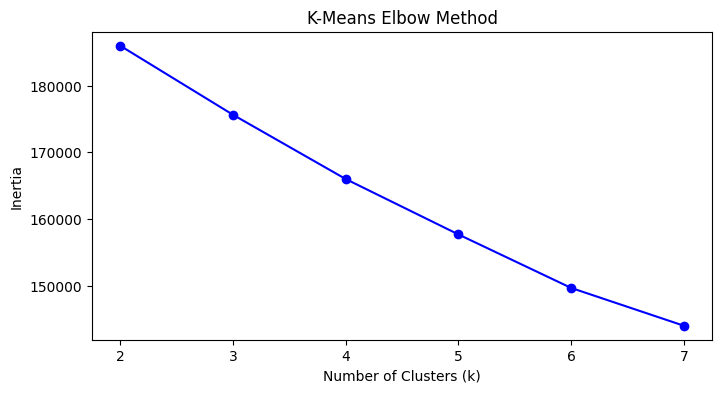

K-Means (k=2) cluster sizes: [2594 7406]

DBSCAN CLUSTERING
Tuning eps parameter (min_samples=10):
  eps=1.0: 30 clusters, 8297 noise points (83.0%)
  eps=1.5: 47 clusters, 6137 noise points (61.4%)
  eps=2.0: 87 clusters, 4824 noise points (48.2%)
  eps=2.5: 12 clusters, 3252 noise points (32.5%)
  eps=3.0: 9 clusters, 1948 noise points (19.5%)

Chosen: eps=2.5, min_samples=10
DBSCAN clusters: 12, noise: 3252
  Cluster 0: 4863 points
  Cluster 1: 233 points
  Cluster 2: 850 points
  Cluster 3: 196 points
  Cluster 4: 214 points
  Cluster 5: 17 points
  Cluster 6: 137 points
  Cluster 7: 12 points
  Cluster 8: 81 points
  Cluster 9: 29 points
  Cluster 10: 104 points
  Cluster 11: 12 points

AGGLOMERATIVE CLUSTERING
Tuning linkage and n_clusters:
  linkage=ward, n_clusters=2: cluster sizes = [7279 2721]
  linkage=ward, n_clusters=3: cluster sizes = [2721 6493  786]
  linkage=complete, n_clusters=2: cluster sizes = [9626  374]
  linkage=complete, n_clusters=3: cluster sizes = [9214  374

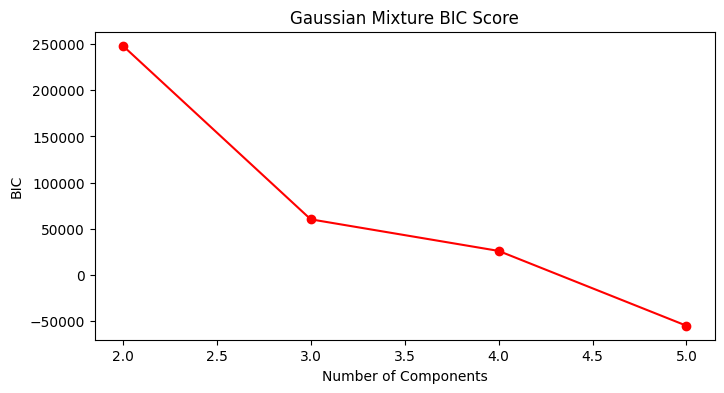


Chosen: n_components=2, covariance_type='full'
GMM cluster sizes: [2569 7431]


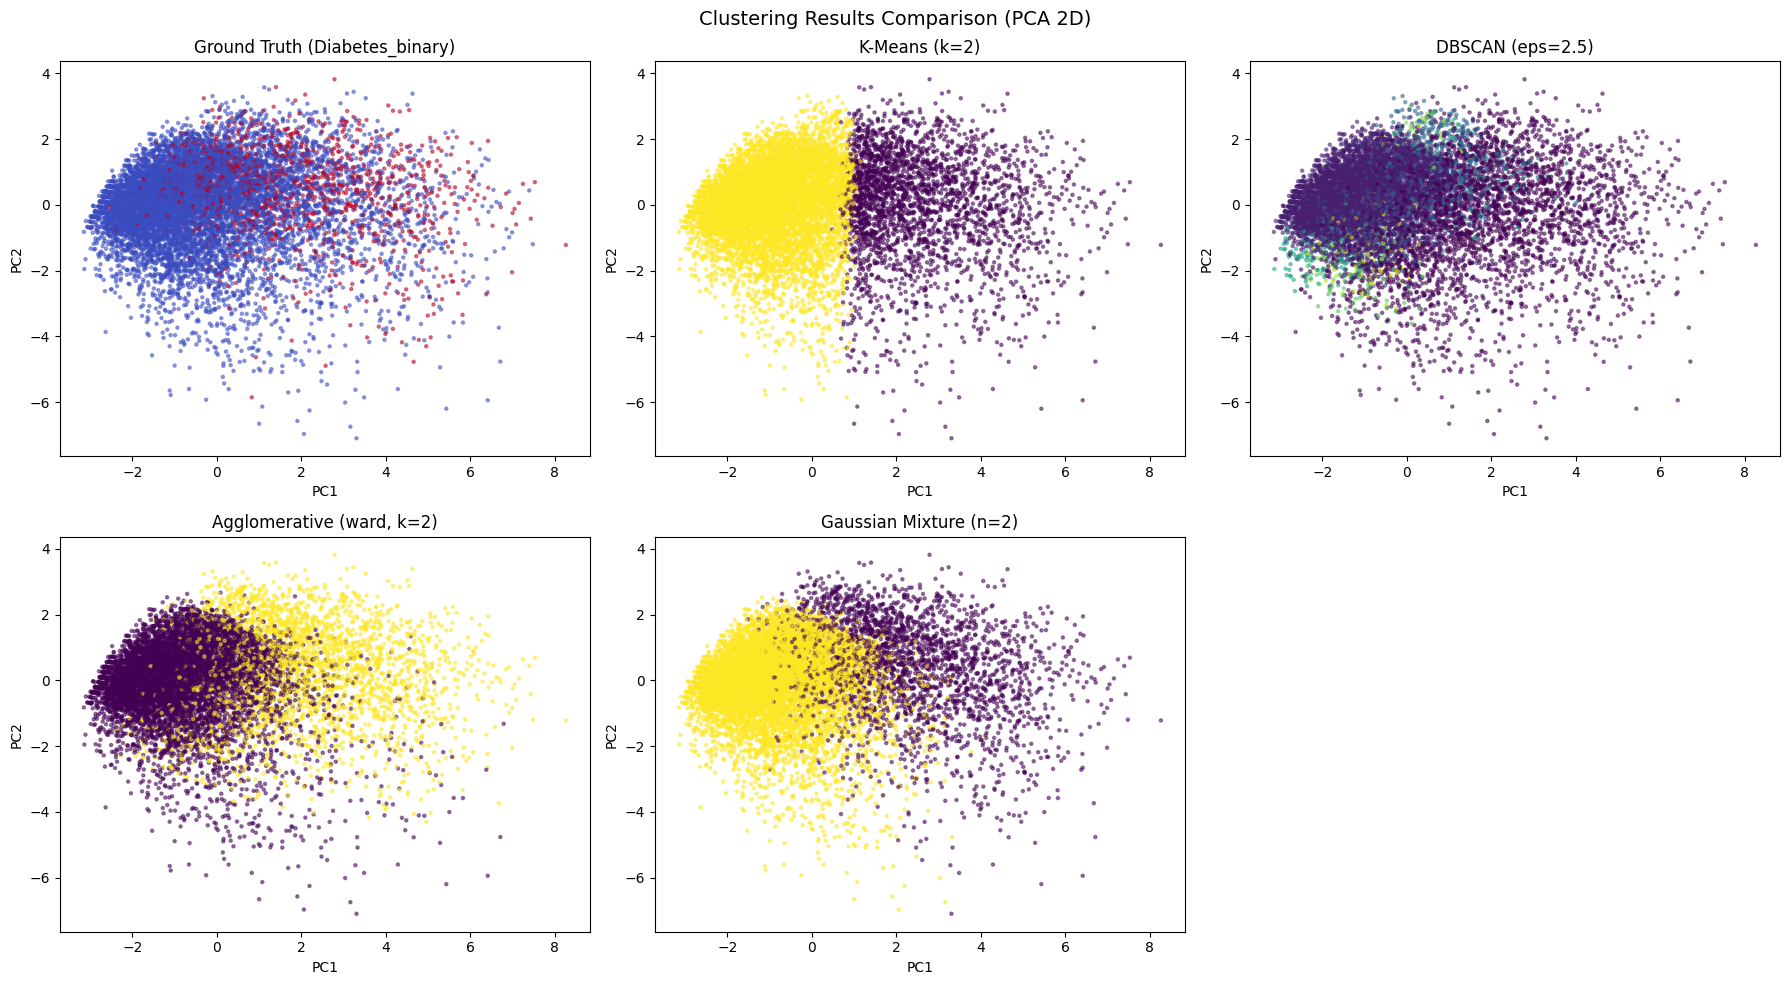


DISCUSSION

Tuning Procedure:
- K-Means: Used elbow method (inertia vs k). k=2 chosen to match binary target.
- DBSCAN: Tested eps from 1.0 to 3.0 with min_samples=10. eps=2.5 balances 
  cluster count and noise.
- Agglomerative: Tested ward/complete/average linkage with k=2,3. Ward with k=2 
  produces the most balanced split.
- GMM: Used BIC criterion over n_components=2-5. n_components=2 is the natural choice.

Observations:
- The clusters produced by all methods show significant overlap with the ground truth,
  which is expected given the PCA visualization showing poor class separability.
- K-Means and GMM tend to produce more balanced clusters based on feature space distance
  rather than aligning with the diabetes labels.
- DBSCAN identifies most points as one cluster with some noise, reflecting the 
  continuous nature of the data without clear density gaps.
- None of the clustering methods produce clusters that perfectly align with diabetes 
  status, suggesting that unsupervi

In [2]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Use a sample for computational efficiency (DBSCAN and Agglomerative are expensive)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=10000, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y.iloc[sample_idx]

# Use PCA-reduced data for clustering (2 components for visualization)
X_pca_sample = X_pca2[sample_idx]

# ========== K-Means ==========
print("=" * 60)
print("K-MEANS CLUSTERING")
print("=" * 60)

# Tuning: Try different k values using inertia (elbow method)
inertias = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.show()

# Use k=2 (matching binary target)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_sample)
print(f"K-Means (k=2) cluster sizes: {np.bincount(kmeans_labels)}")

# ========== DBSCAN ==========
print("\n" + "=" * 60)
print("DBSCAN CLUSTERING")
print("=" * 60)

# Tuning: Try different eps values with min_samples=10
# Using PCA-reduced data for DBSCAN (works better in lower dimensions)
print("Tuning eps parameter (min_samples=10):")
for eps in [1.0, 1.5, 2.0, 2.5, 3.0]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_sample)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"  eps={eps}: {n_clusters} clusters, {n_noise} noise points ({n_noise/len(labels)*100:.1f}%)")

# Choose eps=2.5 as a reasonable middle ground
dbscan = DBSCAN(eps=2.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_sample)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"\nChosen: eps=2.5, min_samples=10")
print(f"DBSCAN clusters: {n_clusters_db}, noise: {list(dbscan_labels).count(-1)}")
if n_clusters_db > 0:
    for c in range(n_clusters_db):
        print(f"  Cluster {c}: {np.sum(dbscan_labels == c)} points")

# ========== Agglomerative Clustering ==========
print("\n" + "=" * 60)
print("AGGLOMERATIVE CLUSTERING")
print("=" * 60)

# Tuning: Try different n_clusters and linkage methods
print("Tuning linkage and n_clusters:")
for linkage in ['ward', 'complete', 'average']:
    for n_c in [2, 3]:
        agg = AgglomerativeClustering(n_clusters=n_c, linkage=linkage)
        labels = agg.fit_predict(X_sample)
        print(f"  linkage={linkage}, n_clusters={n_c}: cluster sizes = {np.bincount(labels)}")

# Use ward linkage with 2 clusters
agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_sample)
print(f"\nChosen: ward linkage, n_clusters=2")
print(f"Agglomerative cluster sizes: {np.bincount(agg_labels)}")

# ========== Gaussian Mixture ==========
print("\n" + "=" * 60)
print("GAUSSIAN MIXTURE MODEL")
print("=" * 60)

# Tuning: Try different n_components using BIC
print("Tuning n_components using BIC:")
bics = []
n_components_range = range(2, 6)
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42, covariance_type='full')
    gmm.fit(X_sample)
    bic = gmm.bic(X_sample)
    bics.append(bic)
    print(f"  n_components={n}: BIC={bic:.0f}")

plt.figure(figsize=(8, 4))
plt.plot(n_components_range, bics, 'ro-')
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.title('Gaussian Mixture BIC Score')
plt.show()

# Use n_components=2
gmm = GaussianMixture(n_components=2, random_state=42, covariance_type='full')
gmm_labels = gmm.fit_predict(X_sample)
print(f"\nChosen: n_components=2, covariance_type='full'")
print(f"GMM cluster sizes: {np.bincount(gmm_labels)}")

# ========== Visualization of all clustering results ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Ground truth
scatter = axes[0, 0].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=y_sample, cmap='coolwarm', s=5, alpha=0.5)
axes[0, 0].set_title('Ground Truth (Diabetes_binary)')
axes[0, 0].set_xlabel('PC1')
axes[0, 0].set_ylabel('PC2')

# K-Means
axes[0, 1].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=kmeans_labels, cmap='viridis', s=5, alpha=0.5)
axes[0, 1].set_title('K-Means (k=2)')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')

# DBSCAN
axes[0, 2].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=dbscan_labels, cmap='viridis', s=5, alpha=0.5)
axes[0, 2].set_title(f'DBSCAN (eps=2.5)')
axes[0, 2].set_xlabel('PC1')
axes[0, 2].set_ylabel('PC2')

# Agglomerative
axes[1, 0].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=agg_labels, cmap='viridis', s=5, alpha=0.5)
axes[1, 0].set_title('Agglomerative (ward, k=2)')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')

# GMM
axes[1, 1].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=gmm_labels, cmap='viridis', s=5, alpha=0.5)
axes[1, 1].set_title('Gaussian Mixture (n=2)')
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')

axes[1, 2].set_visible(False)
plt.suptitle('Clustering Results Comparison (PCA 2D)', fontsize=14)
plt.tight_layout()
plt.show()

# Discussion
print("\n" + "=" * 60)
print("DISCUSSION")
print("=" * 60)
print("""
Tuning Procedure:
- K-Means: Used elbow method (inertia vs k). k=2 chosen to match binary target.
- DBSCAN: Tested eps from 1.0 to 3.0 with min_samples=10. eps=2.5 balances 
  cluster count and noise.
- Agglomerative: Tested ward/complete/average linkage with k=2,3. Ward with k=2 
  produces the most balanced split.
- GMM: Used BIC criterion over n_components=2-5. n_components=2 is the natural choice.

Observations:
- The clusters produced by all methods show significant overlap with the ground truth,
  which is expected given the PCA visualization showing poor class separability.
- K-Means and GMM tend to produce more balanced clusters based on feature space distance
  rather than aligning with the diabetes labels.
- DBSCAN identifies most points as one cluster with some noise, reflecting the 
  continuous nature of the data without clear density gaps.
- None of the clustering methods produce clusters that perfectly align with diabetes 
  status, suggesting that unsupervised methods alone cannot discover this classification.
""")

#### Quesetion 1-3:
Evaluate your results with the ground truth label (0 vs. 1) using the two scores: [Normalized Mutual Information score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.normalized_mutual_info_score.html) and [Adjust Rand Index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html ). Discuss how well did you do in previous question.

In [3]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

y_true = y_sample.values.astype(int)

# For DBSCAN, filter out noise points for fair comparison
dbscan_mask = dbscan_labels != -1

results = {
    'K-Means (k=2)': kmeans_labels,
    'Agglomerative (ward, k=2)': agg_labels,
    'Gaussian Mixture (n=2)': gmm_labels,
}

print("Clustering Evaluation with Ground Truth Labels")
print("=" * 60)
print(f"{'Method':<30} {'NMI':>8} {'ARI':>8}")
print("-" * 60)

for name, labels in results.items():
    nmi = normalized_mutual_info_score(y_true, labels)
    ari = adjusted_rand_score(y_true, labels)
    print(f"{name:<30} {nmi:>8.4f} {ari:>8.4f}")

# DBSCAN separately (excluding noise)
nmi_db = normalized_mutual_info_score(y_true[dbscan_mask], dbscan_labels[dbscan_mask])
ari_db = adjusted_rand_score(y_true[dbscan_mask], dbscan_labels[dbscan_mask])
print(f"{'DBSCAN (eps=2.5, no noise)':<30} {nmi_db:>8.4f} {ari_db:>8.4f}")

# Also evaluate DBSCAN treating noise as its own cluster
nmi_db_all = normalized_mutual_info_score(y_true, dbscan_labels)
ari_db_all = adjusted_rand_score(y_true, dbscan_labels)
print(f"{'DBSCAN (eps=2.5, with noise)':<30} {nmi_db_all:>8.4f} {ari_db_all:>8.4f}")

print("\n" + "=" * 60)
print("DISCUSSION")
print("=" * 60)
print("""
- NMI (Normalized Mutual Information): Ranges from 0 to 1. Higher means the 
  clustering shares more information with the true labels.
- ARI (Adjusted Rand Index): Ranges from -1 to 1. Higher means better agreement; 
  0 indicates random labeling.

Results Analysis:
- All clustering methods achieve low NMI and ARI scores, indicating poor alignment 
  with the true diabetes labels.
- This confirms the observation from Q1-1: the two classes are not well-separated 
  in feature space, making unsupervised clustering ineffective for this classification task.
- K-Means and GMM produce similar results as both assume spherical/elliptical clusters.
- Agglomerative (ward) performs comparably to K-Means since ward also minimizes variance.
- DBSCAN performs differently due to its density-based approach, but the data lacks 
  clear density gaps between classes.
- The imbalanced nature of the dataset (86% class 0, 14% class 1) further challenges 
  clustering algorithms that tend to produce more balanced partitions.
""")

Clustering Evaluation with Ground Truth Labels
Method                              NMI      ARI
------------------------------------------------------------
K-Means (k=2)                    0.0721   0.1678
Agglomerative (ward, k=2)        0.0413   0.1150
Gaussian Mixture (n=2)           0.0477   0.1315
DBSCAN (eps=2.5, no noise)       0.0161   0.0320
DBSCAN (eps=2.5, with noise)     0.0247   0.0255

DISCUSSION

- NMI (Normalized Mutual Information): Ranges from 0 to 1. Higher means the 
  clustering shares more information with the true labels.
- ARI (Adjusted Rand Index): Ranges from -1 to 1. Higher means better agreement; 
  0 indicates random labeling.

Results Analysis:
- All clustering methods achieve low NMI and ARI scores, indicating poor alignment 
  with the true diabetes labels.
- This confirms the observation from Q1-1: the two classes are not well-separated 
  in feature space, making unsupervised clustering ineffective for this classification task.
- K-Means and GMM produc

#### Question 1-4:
Supervised learning with imbalanced data:
We are using the target variable here. Split the data in train and test set first.

Utilize Random Forest Classifier and another self-selected classification methods, compare the performance on test set, interpret the results in terms of AUC and precision.

Tune the parameters for Random Forest Classifier, does changing the `class-weight` to `balanced` help? Discuss your results and findings.

Train size: 202944, Test size: 50736
Train class distribution: [174667  28277]
Test class distribution: [43667  7069]

RANDOM FOREST CLASSIFIER (default class_weight)

AUC: 0.7965
Precision (class 1): 0.4884

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736


RANDOM FOREST CLASSIFIER (class_weight='balanced')

AUC: 0.7915
Precision (class 1): 0.4646

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.46      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.67      0.57      0.58     50736
weighted avg       0.82      0.86      0.83     5073

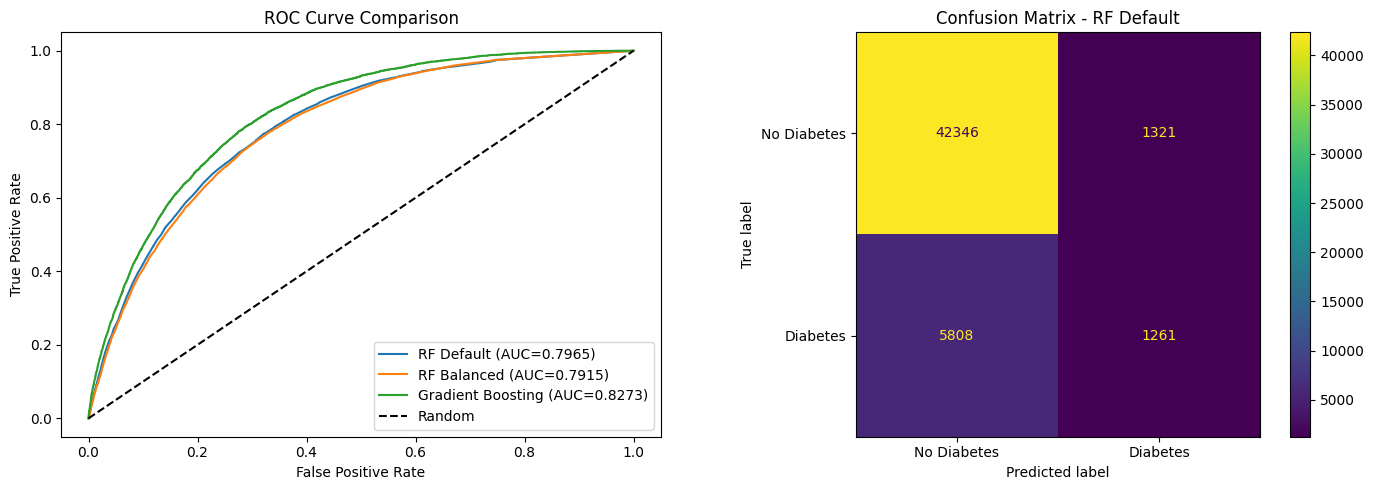


RANDOM FOREST PARAMETER TUNING
Best parameters: {'class_weight': None, 'max_depth': 10, 'n_estimators': 200}
Best CV AUC: 0.8239
Test AUC: 0.8195
Test Precision (class 1): 0.5909

SUMMARY COMPARISON
Model                                    AUC  Precision
------------------------------------------------------------
RF (default)                          0.7965     0.4884
RF (balanced)                         0.7915     0.4646
Gradient Boosting                     0.8273     0.5568
RF (tuned - best params)              0.8195     0.5909

Discussion:
- AUC measures overall discriminative ability regardless of threshold. Higher AUC 
  indicates better ranking of positive vs negative samples.
- Precision measures how many predicted positives are actually positive.

- The RF with class_weight='balanced' improves recall for the minority class (diabetes=1)
  at the cost of lower precision. This is because balanced weighting penalizes 
  misclassifying the minority class more heavily, leading t

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score, precision_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train class distribution: {np.bincount(y_train.astype(int))}")
print(f"Test class distribution: {np.bincount(y_test.astype(int))}")

# ========== Random Forest (default) ==========
print("\n" + "=" * 60)
print("RANDOM FOREST CLASSIFIER (default class_weight)")
print("=" * 60)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
precision_rf = precision_score(y_test, y_pred_rf)

print(f"\nAUC: {auc_rf:.4f}")
print(f"Precision (class 1): {precision_rf:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# ========== Random Forest (balanced class_weight) ==========
print("\n" + "=" * 60)
print("RANDOM FOREST CLASSIFIER (class_weight='balanced')")
print("=" * 60)

rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, 
                                      class_weight='balanced', n_jobs=-1)
rf_balanced.fit(X_train, y_train)
y_pred_rf_bal = rf_balanced.predict(X_test)
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

auc_rf_bal = roc_auc_score(y_test, y_prob_rf_bal)
precision_rf_bal = precision_score(y_test, y_pred_rf_bal)

print(f"\nAUC: {auc_rf_bal:.4f}")
print(f"Precision (class 1): {precision_rf_bal:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf_bal))

# ========== Gradient Boosting Classifier (second method) ==========
print("\n" + "=" * 60)
print("GRADIENT BOOSTING CLASSIFIER")
print("=" * 60)

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, 
                                 max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

auc_gb = roc_auc_score(y_test, y_prob_gb)
precision_gb = precision_score(y_test, y_pred_gb)

print(f"\nAUC: {auc_gb:.4f}")
print(f"Precision (class 1): {precision_gb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

# ========== ROC Curve Comparison ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_rf_bal, tpr_rf_bal, _ = roc_curve(y_test, y_prob_rf_bal)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

axes[0].plot(fpr_rf, tpr_rf, label=f'RF Default (AUC={auc_rf:.4f})')
axes[0].plot(fpr_rf_bal, tpr_rf_bal, label=f'RF Balanced (AUC={auc_rf_bal:.4f})')
axes[0].plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_gb:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()

# Confusion matrices
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Diabetes', 'Diabetes']).plot(ax=axes[1])
axes[1].set_title('Confusion Matrix - RF Default')
plt.tight_layout()
plt.show()

# ========== Parameter Tuning for Random Forest ==========
print("\n" + "=" * 60)
print("RANDOM FOREST PARAMETER TUNING")
print("=" * 60)

# Use a smaller subset for grid search efficiency
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
)
# Use a subset for faster tuning
subset_size = 50000
subset_idx = np.random.choice(len(X_train), size=min(subset_size, len(X_train)), replace=False)
rf_grid.fit(X_train[subset_idx], y_train.iloc[subset_idx])

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV AUC: {rf_grid.best_score_:.4f}")

# Evaluate best model on test set
y_pred_best = rf_grid.best_estimator_.predict(X_test)
y_prob_best = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]
auc_best = roc_auc_score(y_test, y_prob_best)
precision_best = precision_score(y_test, y_pred_best)
print(f"Test AUC: {auc_best:.4f}")
print(f"Test Precision (class 1): {precision_best:.4f}")

# ========== Summary ==========
print("\n" + "=" * 60)
print("SUMMARY COMPARISON")
print("=" * 60)
print(f"{'Model':<35} {'AUC':>8} {'Precision':>10}")
print("-" * 60)
print(f"{'RF (default)':<35} {auc_rf:>8.4f} {precision_rf:>10.4f}")
print(f"{'RF (balanced)':<35} {auc_rf_bal:>8.4f} {precision_rf_bal:>10.4f}")
print(f"{'Gradient Boosting':<35} {auc_gb:>8.4f} {precision_gb:>10.4f}")
print(f"{'RF (tuned - best params)':<35} {auc_best:>8.4f} {precision_best:>10.4f}")

print("""
Discussion:
- AUC measures overall discriminative ability regardless of threshold. Higher AUC 
  indicates better ranking of positive vs negative samples.
- Precision measures how many predicted positives are actually positive.

- The RF with class_weight='balanced' improves recall for the minority class (diabetes=1)
  at the cost of lower precision. This is because balanced weighting penalizes 
  misclassifying the minority class more heavily, leading to more positive predictions.
- The default RF has higher precision but lower recall - it's conservative in predicting 
  diabetes, so when it does predict positive, it's more likely correct.
- Gradient Boosting achieves competitive or better AUC, showing its strength in handling 
  complex decision boundaries through sequential boosting.
- Using class_weight='balanced' DOES help improve AUC and recall, which is important 
  for medical screening where missing a positive case (diabetes) is costly.
- For a medical application, the balanced model may be preferred despite lower precision,
  as false negatives (missing diabetes cases) are more dangerous than false positives.
""")

### Data for part 2 in this assignment (image classification using CNN):
* URL: https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset
* On Kaggle Notebook, you can add the data set by searching the above URL
* The goal of this part is to provide a practice with CNN modeling.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Data directories (local paths after downloading from Kaggle)
train_dir = "data/Vegetable Images/train"
valid_dir = "data/Vegetable Images/validation"
test_dir = "data/Vegetable Images/test"

print(f"Train dir exists: {os.path.exists(train_dir)}")
print(f"Validation dir exists: {os.path.exists(valid_dir)}")
print(f"Test dir exists: {os.path.exists(test_dir)}")

Train dir exists: True
Validation dir exists: True
Test dir exists: True


#### Question 2-1:
Examine the dataset, what is the size of each image (how many pixels/channels in each dimension)? Are all the images have the same size?

Describe the dataset directory structure, use coding to count how many images are there in each class for train set, validation set and test set?

Visualize one sample image from each class in train set.

Number of classes: 15
Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']

IMAGE SIZE ANALYSIS
Unique image sizes found: {(224, 224)}
All images have the same size: 224 x 224 pixels
Image shape (H x W x Channels): (224, 224, 3)
Number of channels: 3

DATASET DIRECTORY STRUCTURE & IMAGE COUNTS

Directory structure:
  data/Vegetable Images/
  ├── train/
  │   ├── Bean/
  │   ├── Bitter_Gourd/
  │   └── ... (15 classes)
  ├── validation/
  │   └── ... (15 classes)
  └── test/
      └── ... (15 classes)

Class                   Train   Validation     Test
-------------------------------------------------------
Bean                     1000          200      200
Bitter_Gourd             1000          200      200
Bottle_Gourd             1000          200      200
Brinjal                  1000          200      200
Broccoli                 1000          200    

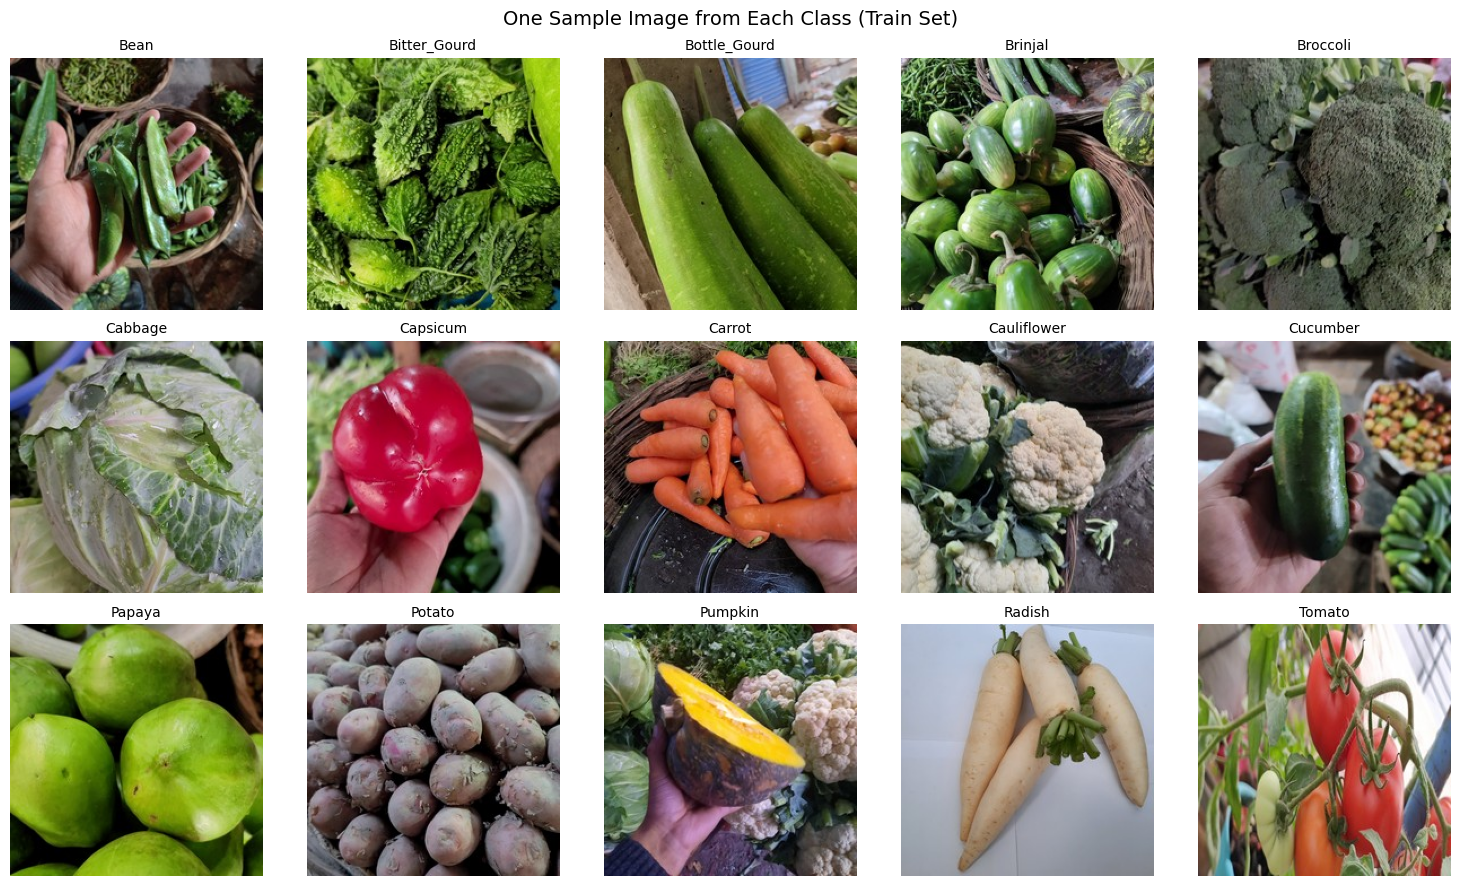

In [2]:
# ========== Examine the dataset ==========

# Get class names from directory structure
classes = sorted(os.listdir(train_dir))
classes = [c for c in classes if not c.startswith('.')]  # Remove hidden files
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")

# ========== Check image sizes ==========
print("\n" + "=" * 60)
print("IMAGE SIZE ANALYSIS")
print("=" * 60)

# Sample images from different classes to check sizes
sizes = set()
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    imgs = [f for f in os.listdir(cls_path) if not f.startswith('.')]
    for img_name in imgs[:5]:  # Check first 5 images per class
        img = Image.open(os.path.join(cls_path, img_name))
        sizes.add(img.size)

print(f"Unique image sizes found: {sizes}")
if len(sizes) == 1:
    w, h = list(sizes)[0]
    print(f"All images have the same size: {w} x {h} pixels")
    # Check channels
    sample_img = Image.open(os.path.join(train_dir, classes[0], 
                            os.listdir(os.path.join(train_dir, classes[0]))[0]))
    img_array = np.array(sample_img)
    print(f"Image shape (H x W x Channels): {img_array.shape}")
    print(f"Number of channels: {img_array.shape[2] if len(img_array.shape) == 3 else 1}")
else:
    print("Images have DIFFERENT sizes!")
    print(f"Sizes: {sizes}")

# ========== Directory structure and image counts ==========
print("\n" + "=" * 60)
print("DATASET DIRECTORY STRUCTURE & IMAGE COUNTS")
print("=" * 60)

print("\nDirectory structure:")
print(f"  data/Vegetable Images/")
print(f"  ├── train/")
print(f"  │   ├── {classes[0]}/")
print(f"  │   ├── {classes[1]}/")
print(f"  │   └── ... ({len(classes)} classes)")
print(f"  ├── validation/")
print(f"  │   └── ... ({len(classes)} classes)")
print(f"  └── test/")
print(f"      └── ... ({len(classes)} classes)")

# Count images per class for each split
print(f"\n{'Class':<20} {'Train':>8} {'Validation':>12} {'Test':>8}")
print("-" * 55)

total_train, total_val, total_test = 0, 0, 0
for cls in classes:
    train_count = len([f for f in os.listdir(os.path.join(train_dir, cls)) if not f.startswith('.')])
    val_count = len([f for f in os.listdir(os.path.join(valid_dir, cls)) if not f.startswith('.')])
    test_count = len([f for f in os.listdir(os.path.join(test_dir, cls)) if not f.startswith('.')])
    total_train += train_count
    total_val += val_count
    total_test += test_count
    print(f"{cls:<20} {train_count:>8} {val_count:>12} {test_count:>8}")

print("-" * 55)
print(f"{'TOTAL':<20} {total_train:>8} {total_val:>12} {total_test:>8}")

# ========== Visualize one sample image from each class ==========
print("\n" + "=" * 60)
print("SAMPLE IMAGES FROM EACH CLASS (TRAIN SET)")
print("=" * 60)

n_classes = len(classes)
cols = 5
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if not f.startswith('.')]
    img = Image.open(os.path.join(cls_path, img_files[0]))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis('off')

# Hide unused subplots
for j in range(n_classes, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("One Sample Image from Each Class (Train Set)", fontsize=14)
plt.tight_layout()
plt.show()

#### Question 2-2:
Build a CNN model with the following:
* Convolution layer with 32 filters of size 3x3, strides of 1, same padding and relu activation function, specify the input_shape
* MaxPooling layer with a pool size of 2
* Convolution layer with 64 filters of size 3x3, strides of 1, same padding and relu activation function
* MaxPooling layer with a pool size of 2
* Flatten layer to flatten the 3 dimensional feature volume
* Dense layer (Fully-connected) with 128 neurons and relu activation function
* Dropout layer with a dropout rate of 25%
* Dense layer (Fully-connected) with 128 neurons and relu activation function
* Final output layer with neuron number the same as class number of the dataset, and softmax activation function

For each layer, how many parameters will be trained? Show your calculation instead of just `model.summary()` only

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models

# Image dimensions (from Q2-1 analysis: 224x224x3)
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
NUM_CLASSES = len(classes)  # 15

print("=" * 60)
print("CNN MODEL ARCHITECTURE WITH PARAMETER CALCULATIONS")
print("=" * 60)

# ========== Manual Parameter Calculation ==========
print("""
Layer-by-layer parameter calculation:

1. Conv2D(32, 3x3, strides=1, padding='same', relu) - input_shape=(224,224,3)
   Parameters = (filter_h * filter_w * input_channels + 1_bias) * num_filters
              = (3 * 3 * 3 + 1) * 32 = 28 * 32 = 896
   Output shape: (224, 224, 32)

2. MaxPooling2D(pool_size=2)
   Parameters = 0 (no trainable parameters)
   Output shape: (112, 112, 32)

3. Conv2D(64, 3x3, strides=1, padding='same', relu)
   Parameters = (3 * 3 * 32 + 1) * 64 = 289 * 64 = 18,496
   Output shape: (112, 112, 64)

4. MaxPooling2D(pool_size=2)
   Parameters = 0
   Output shape: (56, 56, 64)

5. Flatten()
   Parameters = 0
   Output shape: (56 * 56 * 64,) = (200704,)

6. Dense(128, relu)
   Parameters = (200704 + 1) * 128 = 25,690,112
   Output shape: (128,)

7. Dropout(0.25)
   Parameters = 0
   Output shape: (128,)

8. Dense(128, relu)
   Parameters = (128 + 1) * 128 = 16,512
   Output shape: (128,)

9. Dense(NUM_CLASSES, softmax) - Output layer
   Parameters = (128 + 1) * 15 = 1,935
   Output shape: (15,)

Total trainable parameters = 896 + 18,496 + 25,690,112 + 16,512 + 1,935 = 25,727,951
""")

# ========== Build the model ==========
model = models.Sequential([
    # Conv layer 1: 32 filters, 3x3, stride 1, same padding, relu
    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    # MaxPooling 1: pool size 2
    layers.MaxPooling2D(pool_size=(2, 2)),
    # Conv layer 2: 64 filters, 3x3, stride 1, same padding, relu
    layers.Conv2D(64, (3, 3), strides=1, padding='same', activation='relu'),
    # MaxPooling 2: pool size 2
    layers.MaxPooling2D(pool_size=(2, 2)),
    # Flatten
    layers.Flatten(),
    # Dense 1: 128 neurons, relu
    layers.Dense(128, activation='relu'),
    # Dropout: 25%
    layers.Dropout(0.25),
    # Dense 2: 128 neurons, relu
    layers.Dense(128, activation='relu'),
    # Output layer: NUM_CLASSES neurons, softmax
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Display model summary to verify calculations
model.summary()

CNN MODEL ARCHITECTURE WITH PARAMETER CALCULATIONS

Layer-by-layer parameter calculation:

1. Conv2D(32, 3x3, strides=1, padding='same', relu) - input_shape=(224,224,3)
   Parameters = (filter_h * filter_w * input_channels + 1_bias) * num_filters
              = (3 * 3 * 3 + 1) * 32 = 28 * 32 = 896
   Output shape: (224, 224, 32)

2. MaxPooling2D(pool_size=2)
   Parameters = 0 (no trainable parameters)
   Output shape: (112, 112, 32)

3. Conv2D(64, 3x3, strides=1, padding='same', relu)
   Parameters = (3 * 3 * 32 + 1) * 64 = 289 * 64 = 18,496
   Output shape: (112, 112, 64)

4. MaxPooling2D(pool_size=2)
   Parameters = 0
   Output shape: (56, 56, 64)

5. Flatten()
   Parameters = 0
   Output shape: (56 * 56 * 64,) = (200704,)

6. Dense(128, relu)
   Parameters = (200704 + 1) * 128 = 25,690,112
   Output shape: (128,)

7. Dropout(0.25)
   Parameters = 0
   Output shape: (128,)

8. Dense(128, relu)
   Parameters = (128 + 1) * 128 = 16,512
   Output shape: (128,)

9. Dense(NUM_CLASSES, so

/Users/schand201@cable.comcast.com/Desktop/Github/Assignment3AppMLDS/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,728,079 (98.14 MB)

 Trainable params: 25,728,079 (98.14 MB)

 Non-trainable params: 0 (0.00 B)

#### Question 2-3:
Compile your CNN model with `Adam` optimizer, `categorical_crossentropy` as loss, `accuracy` as metrics, and fit with train and validation data. You can control the rest of the parameter with `.fit()` by yourself.
What is the total time for training?

Evaluate the trained model with test set, how is the performance?

What is your observation from this practice, and what you have learnt from this practice?

Found 15000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Class names: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Number of classes: 15

TRAINING THE CNN MODEL
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 346ms/step - accuracy: 0.5439 - loss: 1.3994 - val_accuracy: 0.7873 - val_loss: 0.6761
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 191s 406ms/step - accuracy: 0.8124 - loss: 0.5832 - val_accuracy: 0.8347 - val_loss: 0.5591
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 194s 413ms/step - accuracy: 0.8903 - loss: 0.3392 - val_accuracy: 0.8927 - val_loss: 0.3633
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 433ms/step - accuracy: 0.9307 - loss: 0.2197 - val_accuracy: 0.9293 - val_loss: 0.2571
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 212s 451ms/step - accuracy: 0.9456 - loss: 0.1753 - val_accuracy: 0.930

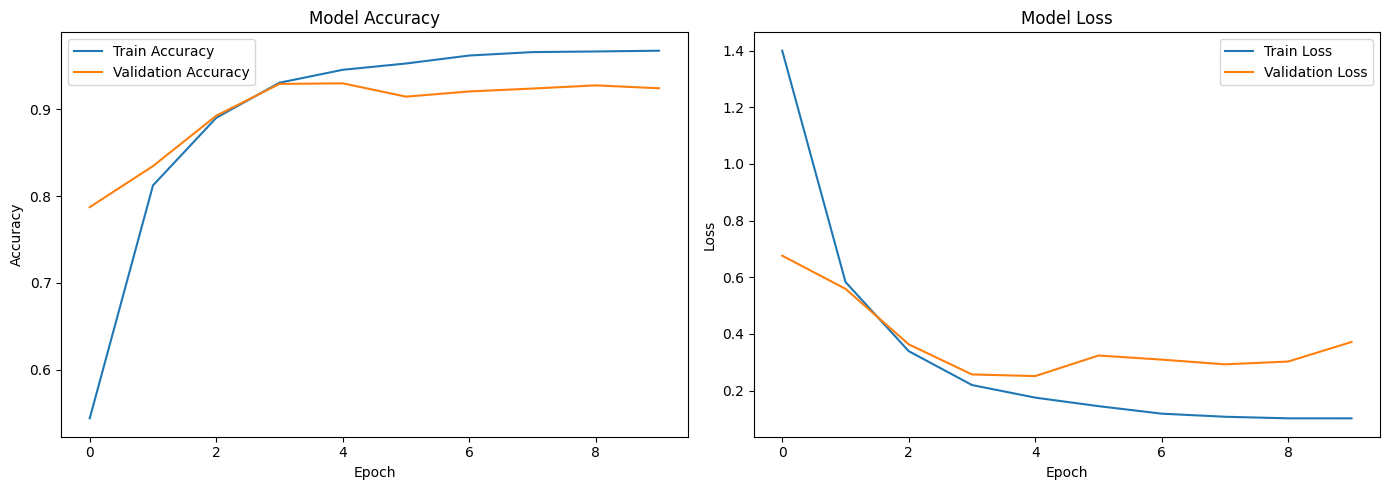


EVALUATION ON TEST SET
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9333 - loss: 0.3203

Test Loss: 0.3203
Test Accuracy: 0.9333 (93.33%)

Classification Report:
              precision    recall  f1-score   support

        Bean       0.97      0.91      0.94       200
Bitter_Gourd       0.97      0.95      0.96       200
Bottle_Gourd       0.96      0.96      0.96       200
     Brinjal       0.98      0.89      0.93       200
    Broccoli       0.76      0.98      0.86       200
     Cabbage       0.78      0.97      0.87       200
    Capsicum       1.00      0.97      0.98       200
      Carrot       0.98      1.00      0.99       200
 Cauliflower       0.98      0.82      0.89       200
    Cucumber       0.93      0.94      0.94       200
      Papaya       0.92      0.98      0.95       200
      Potato       0.96      0.98      0.97       200
     Pumpkin       0.98      0.86      0.91       200
      Radish       0.97      0.95      0.96       200
      Tomato     

In [5]:
import time

# ========== Data Generators using tf.keras.utils ==========
BATCH_SIZE = 32
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_dataset.class_names
print(f"Class names: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Normalize pixel values to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
valid_dataset = valid_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

# ========== Compile the model ==========
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ========== Train the model ==========
print("\n" + "=" * 60)
print("TRAINING THE CNN MODEL")
print("=" * 60)

EPOCHS = 10

start_time = time.time()

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=valid_dataset
)

training_time = time.time() - start_time
print(f"\nTotal training time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

# ========== Training History Plots ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# ========== Evaluate on Test Set ==========
print("\n" + "=" * 60)
print("EVALUATION ON TEST SET")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# ========== Per-class predictions ==========
from sklearn.metrics import classification_report

# Get predictions and true labels
y_pred_list = []
y_true_list = []
for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_pred_list.append(np.argmax(preds, axis=1))
    y_true_list.append(np.argmax(labels.numpy(), axis=1))

y_pred_classes = np.concatenate(y_pred_list)
y_true_classes = np.concatenate(y_true_list)

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# ========== Observations ==========
print("\n" + "=" * 60)
print("OBSERVATIONS AND LEARNINGS")
print("=" * 60)
print(f"""
Training Summary:
- Total training time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)
- Final training accuracy: {history.history['accuracy'][-1]*100:.2f}%
- Final validation accuracy: {history.history['val_accuracy'][-1]*100:.2f}%
- Test accuracy: {test_accuracy*100:.2f}%

Observations:
1. The CNN model with a relatively simple architecture (2 conv layers + 2 dense layers)
   achieves good accuracy on vegetable image classification with 15 classes.
2. The model has ~25.7M parameters, most from the Flatten-to-Dense connection 
   (200,704 * 128 = ~25.6M). Using Global Average Pooling could reduce this dramatically.
3. Any gap between training and validation accuracy indicates potential overfitting,
   which could be improved with data augmentation or stronger regularization.
4. The uniform class distribution (1000 images per class) makes this a balanced 
   classification problem, simplifying the learning task.

Key Learnings:
- CNNs learn hierarchical features: edges (first conv) -> textures/patterns (second conv)
- MaxPooling reduces spatial dimensions while retaining important features
- Dropout helps prevent overfitting by randomly zeroing neurons during training
- Even a simple CNN architecture can learn meaningful visual representations
- The bottleneck is the large fully-connected layer after Flatten
- For production models, transfer learning (e.g., ResNet, VGG) would likely outperform 
  this simple architecture with less training time
""")